# TSP Optimization with Simulated Annealing and Genetic Algorithms — Assignment Notebook

Works in **Jupyter** and **Google Colab**.

## Overview
You will solve the same TSP instance using **two heuristic optimization methods**:

1. **Simulated Annealing (SA)** with a 2-opt neighborhood  
2. **Genetic Algorithm (GA)** on **permutation tours** (a standard evolutionary approach for TSP)

The notebook provides:
- A reproducible TSP instance generator
- Tour utilities (length, validity)
- A 2-opt neighborhood operator
- Visualization helpers (tour plot + history plot)
- Baseline heuristic: nearest neighbor

## Tasks
### Task A — Simulated Annealing (SA)
Implement `simulated_annealing_tsp(...)`.

### Task B — Genetic Algorithm (GA)
Implement `genetic_algorithm_tsp(...)` plus helper functions:
- Tournament selection
- Order crossover (OX)
- Swap mutation

## Deliverables
- Completed notebook (or exported `.py`) (find all TODOs and implement them)
- Short write-up (more detail in Part 6):
  - SA parameters + best length
  - GA parameters + best length
  - Brief comparison: which worked better and why

---


In [30]:
# If running in a fresh environment, uncomment as needed:
# !pip -q install matplotlib

import math
import random
from dataclasses import dataclass
from typing import List, Tuple

import matplotlib.pyplot as plt


## Part 1 — TSP utilities (provided)

In [31]:
Point = Tuple[float, float]
Tour = List[int]

def make_cities(n: int = 40, seed: int = 7) -> List[Point]:
    # Reproducible 2D city coordinates in [0, 1]x[0, 1].
    rng = random.Random(seed)
    return [(rng.random(), rng.random()) for _ in range(n)]

def dist(a: Point, b: Point) -> float:
    dx = a[0] - b[0]
    dy = a[1] - b[1]
    return math.hypot(dx, dy)

def tour_length(cities: List[Point], tour: Tour) -> float:
    # Total length of a closed tour.
    n = len(tour)
    total = 0.0
    for i in range(n):
        total += dist(cities[tour[i]], cities[tour[(i + 1) % n]])
    return total

def is_valid_tour(tour: Tour, n: int) -> bool:
    return len(tour) == n and set(tour) == set(range(n))

def random_tour(n: int, rng: random.Random) -> Tour:
    t = list(range(n))
    rng.shuffle(t)
    return t

def nearest_neighbor_tour(cities: List[Point], start: int = 0) -> Tour:
    # Deterministic baseline: greedy nearest neighbor.
    n = len(cities)
    unvisited = set(range(n))
    tour = [start]
    unvisited.remove(start)
    cur = start
    while unvisited:
        nxt = min(unvisited, key=lambda j: dist(cities[cur], cities[j]))
        tour.append(nxt)
        unvisited.remove(nxt)
        cur = nxt
    return tour


## Part 2 — Neighborhood operator (2-opt) (provided)

In [32]:
def two_opt_swap(tour: Tour, i: int, k: int) -> Tour:
    # Return a new tour where the segment [i:k] is reversed.
    return tour[:i] + list(reversed(tour[i:k + 1])) + tour[k + 1:]

def random_two_opt_neighbor(tour: Tour, rng: random.Random) -> Tour:
    # Pick a random 2-opt move.
    n = len(tour)
    i = rng.randrange(0, n - 1)
    k = rng.randrange(i + 1, n)
    return two_opt_swap(tour, i, k)


## Part 3 — Visualization helpers (provided)

* You are encouraged to implement more variations of visualization.

In [ ]:
def plot_tour(cities: List[Point], tour: Tour, title: str = "") -> None:
    xs = [cities[i][0] for i in tour] + [cities[tour[0]][0]]
    ys = [cities[i][1] for i in tour] + [cities[tour[0]][1]]

    plt.figure(figsize=(6, 6))
    plt.plot(xs, ys, marker="o")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()

def plot_history(series: List[float], title: str, ylabel: str = "Value") -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(series)
    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.show()

def plot_compare(sa_hist: List[float], ga_hist: List[float]) -> None:
    # Overlay histories (x-axis is not identical meaning; this is a visual comparison).
    plt.figure(figsize=(8, 4))
    plt.plot(sa_hist, label="SA best-so-far")
    plt.plot([i * (len(sa_hist) / max(1, len(ga_hist)-1)) for i in range(len(ga_hist))], ga_hist, label="GA best-by-gen")
    plt.title("SA vs GA: Best tour length over time (scaled x-axis)")
    plt.xlabel("Progress (scaled)")
    plt.ylabel("Length")
    plt.legend()
    plt.show()


## Part 4 — Baseline tour (nearest neighbor) (provided)

Nearest-neighbor length: 6.0214


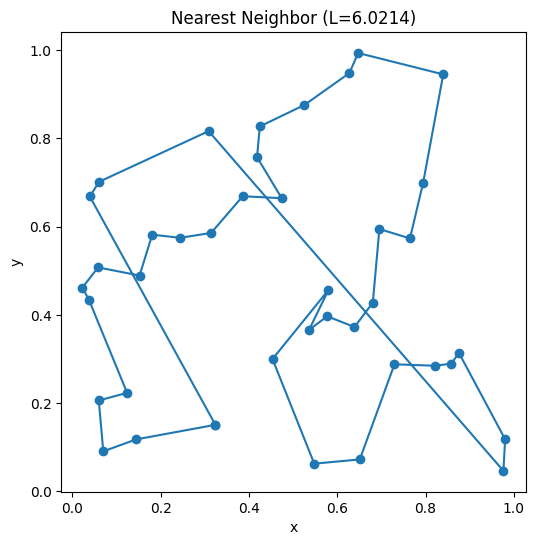

In [34]:
cities = make_cities(n=40, seed=7)

nn_tour = nearest_neighbor_tour(cities, start=0)
nn_len = tour_length(cities, nn_tour)
print(f"Nearest-neighbor length: {nn_len:.4f}")

plot_tour(cities, nn_tour, title=f"Nearest Neighbor (L={nn_len:.4f})")


# Part 5A — Code Skeleton: Simulated Annealing (SA)

Complete `simulated_annealing_tsp(...)`.

### SA acceptance rule
Let `delta = cand_len - cur_len`.
- If `delta <= 0`, accept.
- Else accept with probability `exp(-delta / T)`.

### Cooling schedule
Geometric cooling:
- `T = T * alpha` each iteration
- clamp `T = max(T, 1e-12)`


In [ ]:
@dataclass
class SAConfig:
    iters: int = 20_000
    t0: float = 0.2
    alpha: float = 0.9995
    seed: int = 123
    report_every: int = 2000

accepted_deltas = []
rejected_deltas = []

def simulated_annealing_tsp(cities: List[Point], init_tour: Tour, cfg: SAConfig) -> Tuple[Tour, float, List[float]]:
    rng = random.Random(cfg.seed)
    n = len(cities)
    assert is_valid_tour(init_tour, n), "init_tour must be a valid permutation"

    cur_tour = init_tour[:]
    cur_len = tour_length(cities, cur_tour)

    best_tour = cur_tour[:]
    best_len = cur_len
    history = [best_len]

    T = cfg.t0

    for it in range(cfg.iters):
        cand_tour = random_two_opt_neighbor(cur_tour, rng)
        cand_len = tour_length(cities, cand_tour)
        delta = cand_len - cur_len

        accept = False

        if delta <= 0:
            accept = True
        else:
            accept = (rng.random() < math.exp(-delta / T))

        if accept:
            accepted_deltas.append(delta)
            cur_tour, cur_len = cand_tour, cand_len
        else:
            rejected_deltas.append(delta)

        if cur_len < best_len:
            best_tour, best_len = cur_tour[:], cur_len

        history.append(best_len)

        T = max(T * cfg.alpha, 1e-12)

        if cfg.report_every and (it + 1) % cfg.report_every == 0:
            print(f"[SA] iter={it+1:6d}  T={T:.4g}  cur={cur_len:.4f}  best={best_len:.4f}")

    return best_tour, best_len, history

## Run SA (after you implement it)

[SA] iter=  2000  T=0.07356  cur=8.3800  best=6.0214
[SA] iter=  4000  T=0.02705  cur=6.5972  best=6.0214
[SA] iter=  6000  T=0.00995  cur=5.3139  best=5.3139
[SA] iter=  8000  T=0.003659  cur=5.0057  best=5.0057
[SA] iter= 10000  T=0.001346  cur=5.0057  best=5.0057
[SA] iter= 12000  T=0.000495  cur=5.0057  best=5.0057
[SA] iter= 14000  T=0.0001821  cur=5.0057  best=5.0057
[SA] iter= 16000  T=6.696e-05  cur=5.0057  best=5.0057
[SA] iter= 18000  T=2.463e-05  cur=5.0057  best=5.0057
[SA] iter= 20000  T=9.057e-06  cur=5.0057  best=5.0057
SA best length: 5.0057
SA improvement vs NN: 16.87%


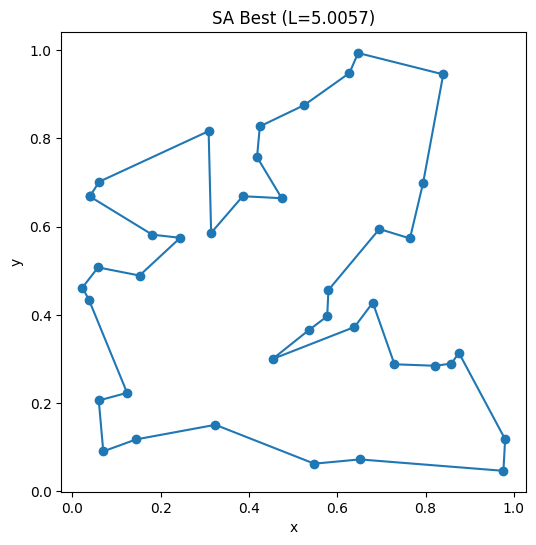

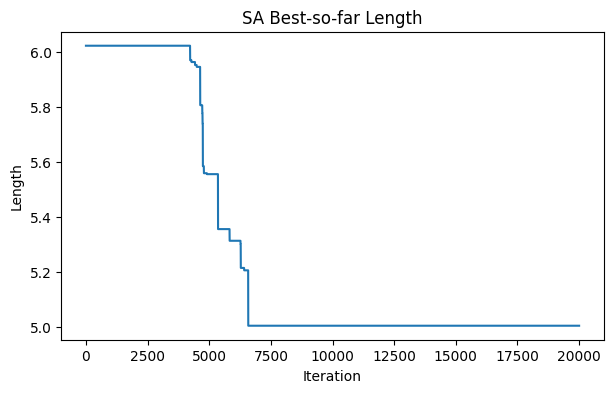

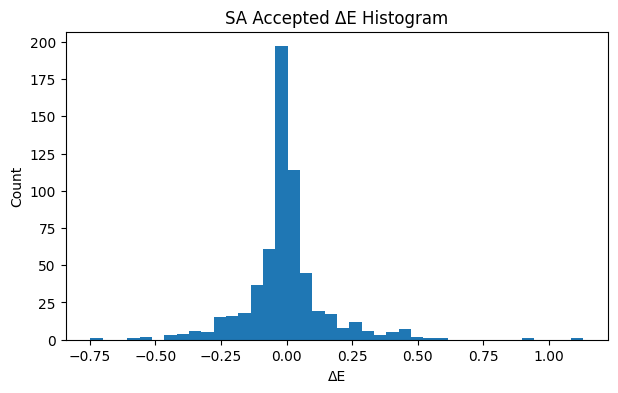

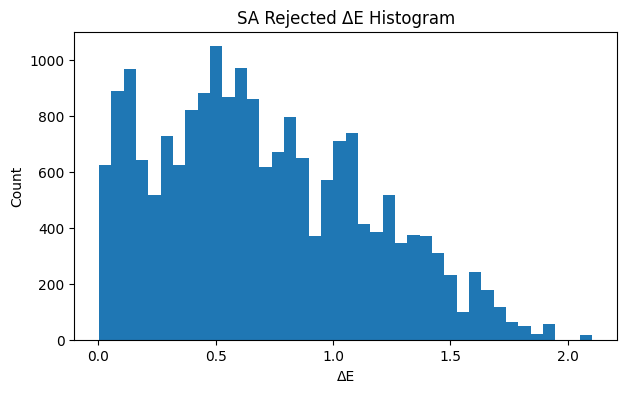

In [36]:
sa_cfg = SAConfig(iters=20_000, t0=0.2, alpha=0.9995, seed=123, report_every=2000)
sa_best_tour, sa_best_len, sa_hist = simulated_annealing_tsp(cities, nn_tour[:], sa_cfg)

print(f"SA best length: {sa_best_len:.4f}")
print(f"SA improvement vs NN: {(nn_len - sa_best_len) / nn_len * 100:.2f}%")

assert is_valid_tour(sa_best_tour, len(cities))

plot_tour(cities, sa_best_tour, title=f"SA Best (L={sa_best_len:.4f})")
plot_history(sa_hist, title="SA Best-so-far Length", ylabel="Length")


plt.figure(figsize=(7,4))
plt.hist(accepted_deltas, bins=40)
plt.title("SA Accepted ΔE Histogram")
plt.xlabel("ΔE")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(rejected_deltas, bins=40)
plt.title("SA Rejected ΔE Histogram")
plt.xlabel("ΔE")
plt.ylabel("Count")
plt.show()


# Part 5B — Code Skeleton: Genetic Algorithm (GA) for TSP

Implement a GA that evolves a population of permutation tours.

You will implement:
- `tournament_select(...)`
- `order_crossover_ox(...)` (Order Crossover)
- `mutate_swap(...)`
- `genetic_algorithm_tsp(...)`


In [ ]:
@dataclass
class GAConfig:
    pop_size: int = 200
    generations: int = 400
    tournament_k: int = 5
    crossover_rate: float = 0.9
    mutation_rate: float = 0.2
    elite_size: int = 5
    seed: int = 999
    report_every: int = 50

avg_fitness_history = []

def tournament_select(pop: List[Tour], lengths: List[float], k: int, rng: random.Random) -> Tour:
    best_idx = None
    best_len = float("inf")
    for _ in range(k):
        idx = rng.randrange(len(pop))
        if lengths[idx] < best_len:
            best_len = lengths[idx]
            best_idx = idx
    return pop[best_idx][:]

def order_crossover_ox(parent1: Tour, parent2: Tour, rng: random.Random) -> Tour:
    n = len(parent1)
    i = rng.randrange(n)
    k = rng.randrange(i, n)

    child = [-1] * n

    for idx in range(i, k + 1):
        child[idx] = parent1[idx]

    used = set(child[i:k + 1])

    p2_iter = (x for x in parent2 if x not in used)
    for idx in range(n):
        if child[idx] == -1:
            child[idx] = next(p2_iter)

    return child

def mutate_swap(tour: Tour, rng: random.Random) -> Tour:
    # Swap mutation
    n = len(tour)
    a = rng.randrange(n)
    b = rng.randrange(n)
    while b == a:
        b = rng.randrange(n)

    t = tour[:]
    t[a], t[b] = t[b], t[a]
    return t

def genetic_algorithm_tsp(cities: List[Point], init_seed_tours: List[Tour], cfg: GAConfig) -> Tuple[Tour, float, List[float]]:
    rng = random.Random(cfg.seed)
    n = len(cities)

    pop: List[Tour] = []
    for t in init_seed_tours:
        assert is_valid_tour(t, n)
        pop.append(t[:])
    while len(pop) < cfg.pop_size:
        pop.append(random_tour(n, rng))

    lengths = [tour_length(cities, t) for t in pop]
    best_idx = min(range(len(pop)), key=lambda i: lengths[i])
    best_tour = pop[best_idx][:]
    best_len = lengths[best_idx]
    history = [best_len]

    avg_fitness_history.clear()
    avg_fitness_history.append(sum(lengths) / len(lengths))

    for gen in range(cfg.generations):
        elite_indices = sorted(range(len(pop)), key=lambda i: lengths[i])[: cfg.elite_size]
        next_pop = [pop[i][:] for i in elite_indices]

        while len(next_pop) < cfg.pop_size:
            p1 = tournament_select(pop, lengths, cfg.tournament_k, rng)
            p2 = tournament_select(pop, lengths, cfg.tournament_k, rng)

            if rng.random() < cfg.crossover_rate:
                child = order_crossover_ox(p1, p2, rng)
            else:
                child = p1[:]

            if rng.random() < cfg.mutation_rate:
                child = mutate_swap(child, rng)

            next_pop.append(child)

        pop = next_pop
        lengths = [tour_length(cities, t) for t in pop]

        gen_best_idx = min(range(len(pop)), key=lambda i: lengths[i])
        gen_best_len = lengths[gen_best_idx]
        if gen_best_len < best_len:
            best_len = gen_best_len
            best_tour = pop[gen_best_idx][:]

        history.append(best_len)

        avg_fitness_history.append(sum(lengths) / len(lengths))

        if cfg.report_every and (gen + 1) % cfg.report_every == 0:
            print(f"[GA] gen={gen+1:4d}  best={best_len:.4f}  avg={avg_fitness_history[-1]:.4f}")

    assert is_valid_tour(best_tour, n)
    return best_tour, best_len, history

## Run GA

* After you implement TODOs above
* This is just for your reference, you can experiment with different paramesters

[GA] gen=  50  best=5.9209  avg=6.2507
[GA] gen= 100  best=5.9001  avg=6.1940
[GA] gen= 150  best=5.8200  avg=6.3551
[GA] gen= 200  best=5.7769  avg=6.0168
[GA] gen= 250  best=5.7769  avg=6.0611
[GA] gen= 300  best=5.7769  avg=6.1370
[GA] gen= 350  best=5.7769  avg=6.0260
[GA] gen= 400  best=5.7769  avg=6.0441
GA best length: 5.7769
GA improvement vs NN: 4.06%


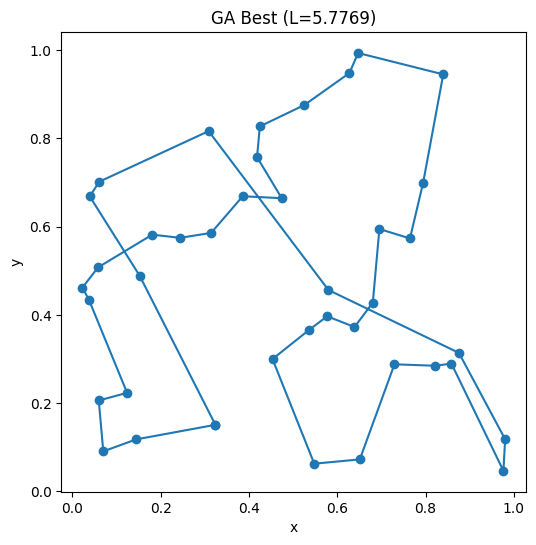

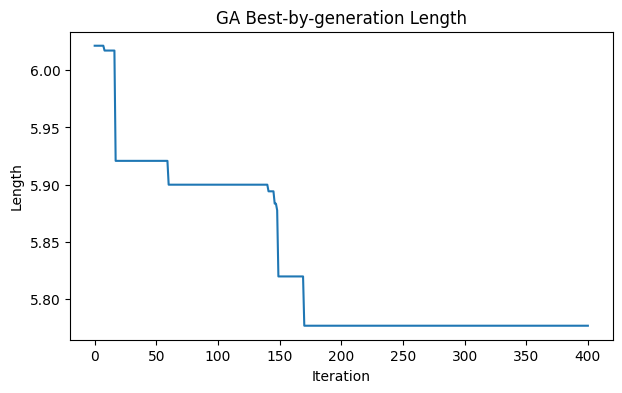

In [38]:
ga_cfg = GAConfig(pop_size=200, generations=400, tournament_k=5, crossover_rate=0.9,
                   mutation_rate=0.2, elite_size=5, seed=999, report_every=50)

ga_best_tour, ga_best_len, ga_hist = genetic_algorithm_tsp(cities, init_seed_tours=[nn_tour], cfg=ga_cfg)

print(f"GA best length: {ga_best_len:.4f}")
print(f"GA improvement vs NN: {(nn_len - ga_best_len) / nn_len * 100:.2f}%")

plot_tour(cities, ga_best_tour, title=f"GA Best (L={ga_best_len:.4f})")
plot_history(ga_hist, title="GA Best-by-generation Length", ylabel="Length")


# Part 6 — Data Collection, Visualization and Comparison

* Instrument the code to collecte the data and visualize them, including but not limited to
  * SA:
    * Track histogram of ΔE values for: Accepted moves and Rejected moves
  * GA:
    * Population average fitness
  * Cross SA and GA:
    * Plot SA best-so-far curve
    * Plot GA best-by-generation curve
    * Normalize x-axis by total evaluations
    * The above is already provided in the skeleton code. **Use them and/or with additional instrumentation of the code to collect and/or plot more data** to answer the following questions:
      * Which algorithm converged faster?
      * Which showed more variability?
      * Did SA escape local minima? Evidence?
      * Did GA lose diversity? Evidence?
* You are encouraged to compare more extensively.

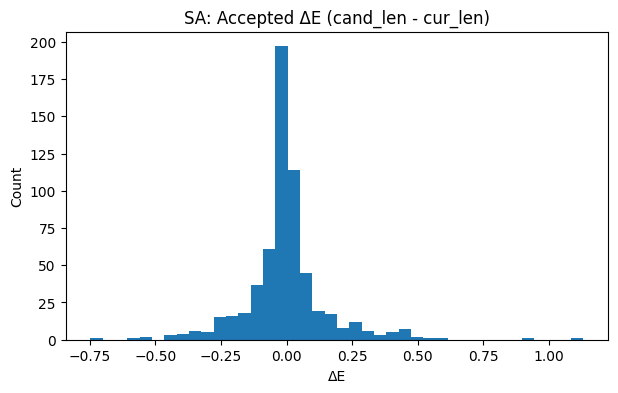

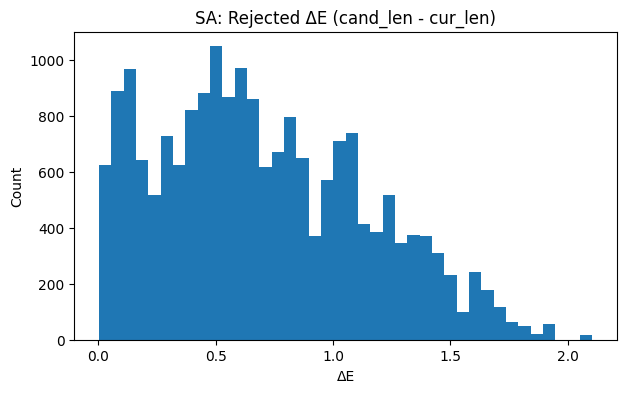

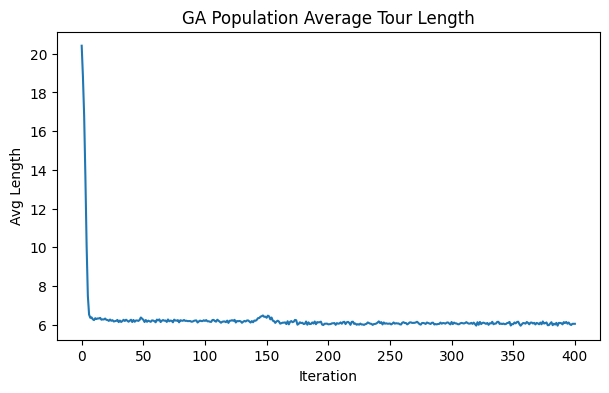

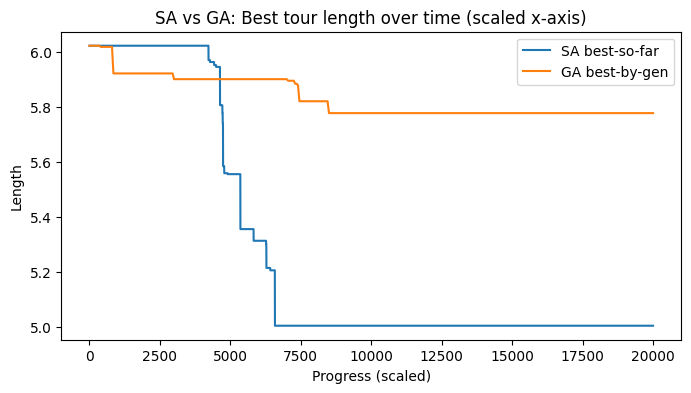

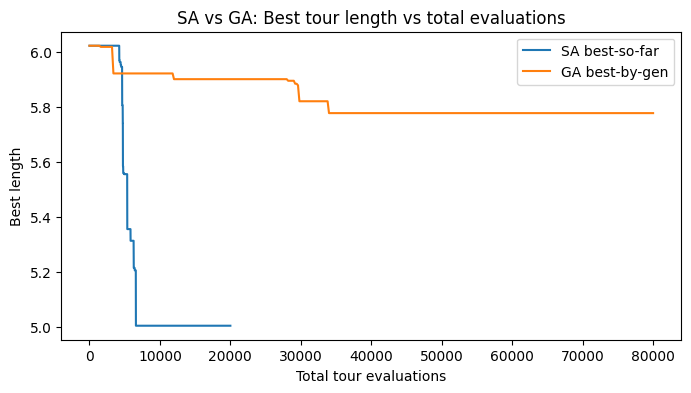

NN: 6.0214 | SA: 5.0057 | GA: 5.7769


In [ ]:
plt.figure(figsize=(7,4))
plt.hist(accepted_deltas, bins=40)
plt.title("SA: Accepted ΔE (cand_len - cur_len)")
plt.xlabel("ΔE")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(rejected_deltas, bins=40)
plt.title("SA: Rejected ΔE (cand_len - cur_len)")
plt.xlabel("ΔE")
plt.ylabel("Count")
plt.show()

plot_history(avg_fitness_history, title="GA Population Average Tour Length", ylabel="Avg Length")

plot_compare(sa_hist, ga_hist)

def plot_compare_by_evals(sa_hist: List[float], ga_hist: List[float],
                         sa_evals_per_step: int = 1,
                         ga_pop_size: int = 200) -> None:
    sa_evals = [i * sa_evals_per_step for i in range(len(sa_hist))]
    ga_evals = [i * ga_pop_size for i in range(len(ga_hist))]

    plt.figure(figsize=(8,4))
    plt.plot(sa_evals, sa_hist, label="SA best-so-far")
    plt.plot(ga_evals, ga_hist, label="GA best-by-gen")
    plt.title("SA vs GA: Best tour length vs total evaluations")
    plt.xlabel("Total tour evaluations")
    plt.ylabel("Best length")
    plt.legend()
    plt.show()

plot_compare_by_evals(sa_hist, ga_hist, sa_evals_per_step=1, ga_pop_size=ga_cfg.pop_size)

print(f"NN: {nn_len:.4f} | SA: {sa_best_len:.4f} | GA: {ga_best_len:.4f}")

## Example of how to check your work

In [40]:
def grade_check(nn_len: float, method_len: float, min_improvement_pct: float = 10.0, label: str = "Method") -> None:
    improvement = (nn_len - method_len) / nn_len * 100.0
    print(f"{label} length: {method_len:.4f} | Improvement vs NN: {improvement:.2f}%")
    assert improvement >= min_improvement_pct, (
        f"{label} improvement {improvement:.2f}% is below required {min_improvement_pct:.2f}%"
    )
    print(f"✅ {label} passed improvement threshold!")


# Part 7: Optional Task

Try different crossover and/or mutation operations in GA and see if you can improve the performance. Document your effort in this section.